## **Estimation the Value Function-Sobol Indices**

This notebook is the companion to the Shapley-value estimation lab. Here we focus on the estimation of the value function. In the classic
variance-based sensitivity analysis setting:

$$v(S) = \frac{\mathrm{Var}(\mathbb{E}[Y \mid X_S])}{\mathrm{Var}(Y)}$$

For a single feature $i$, $v(\{i\})$ is the **first-order Sobol index** $S_i$. The
**total-effect index** $S_T^i = 1 - v(D \setminus \{i\})$ captures $i$'s influence including
all its interactions. This $v(S)$ is exactly the game used by **Shapley effects**
(Owen, 2014; Song, Nelson & Staum, 2016) to turn Sobol-style sensitivity into a Shapley value
— so everything from the previous notebook plugs in directly once you have a good $v(S)$
estimator.

**Modules**, roughly naive → sophisticated:
1. Ground truth: the Ishigami function (closed-form Sobol indices)
2. Naive / brute-force nested Monte Carlo
3. Pick-and-Freeze family: Saltelli, Jansen, and the Janon/Monod "improved" estimator
4. Given-data / rank-based estimation (no paired design needed at all)
5. Grand comparison: error vs. evaluation budget, all methods on one plot
Bonus : Correlated inputs: why Pick-and-Freeze silently breaks, and what to do instead


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from itertools import product

np.set_printoptions(precision=4, suppress=True)


## **Ground truth: the Ishigami function**

The Ishigami function is a standard benchmark in sensitivity analysis precisely *because* its
Sobol indices are known in closed form -- this lets us judge every estimator below against an
exact answer, the same role the brute-force exact Shapley value played in the previous notebook.

$$F(x_1, x_2, x_3) = \sin(x_1) + a\sin^2(x_2) + b\,x_3^4 \sin(x_1), \qquad X_i \sim \mathrm{Uniform}(-\pi, \pi)$$

with the classic parameters $a=7$, $b=0.1$.


## **Implementation of Ishigami function**

In [ ]:
a, b = 7.0, 0.1

def ishigami(X):
    x1, x2, x3 = X[:, 0], X[:, 1], X[:, 2]
    return np.sin(x1) + a * np.sin(x2)**2 + b * (x3**4) * np.sin(x1)

## **Sampling an output of this function with uniform random inputs**

In [ ]:
def sample_inputs(n, rdn):
    return rdn.uniform(-np.pi, np.pi, size=(n, 3))


In [ ]:
#We fix the seed
rdn_seed = np.random.default_rng(0)
#We sample the inputs
X=sample_inputs(200000,rdn_seed)
#We obtain the output
Y= ishigami(X)

## **Calculating first order Sobol indices and Total Effects from closed form formula**

The closed form is well known (see [this website](https://www.sfu.ca/~ssurjano/ishigami.html) with references) and [this paper](https://www.andreasaltelli.eu/file/repository/Sobol_Levitan_1999.pdf) for explicit formulas

In [ ]:
# --- Closed-form (analytic) Sobol indices -- this is our ground truth ---We use the notations used in the paper
D = a**2/8 + b*np.pi**4/5 + b**2*np.pi**8/18 + 0.5     # Var(Y)
D1 = 0.5 * (1 + b*np.pi**4/5)**2                         # variance explained by x1 alone
D2 = a**2/8                                              # variance explained by x2 alone
D3 = 0.0                                                 # x3 alone explains nothing
D13 = 8 * b**2 * np.pi**8 / 225                          # x1-x3 interaction term

S_true = np.array([D1/D, D2/D, D3/D])
T_true = np.array([(D1+D13)/D, D2/D, D13/D])

In [ ]:
print("Analytic first-order S :", np.round(S_true, 4))
print("Analytic total-effect ST:", np.round(T_true, 4))

Analytic first-order S : [0.3139 0.4424 0.    ]
Analytic total-effect ST: [0.5576 0.4424 0.2437]


In [ ]:
print("Sanity check against a very large empirical sample:")
print("Var(Y) empirical:", round(Y.var(), 3), " | analytic D:", round(D, 3))


Sanity check against a very large empirical sample:
Var(Y) empirical: 13.912  | analytic D: 13.845


Notice $S_3 = 0$ (x3 has no first-order effect on its own) but $S_T^3 \approx 0.24 \neq 0$
(x3 *does* matter through its interaction with x1). Any method that can only estimate
first-order indices will completely miss this -- a good reminder of why both indices matter.


In the sequel, we shall estimate these indices using several estimators and compare the estimation and the ground truth

## **Exercise 1 : Naive / brute-force nested Monte Carlo**

The most direct way to estimate $S_i = \mathrm{Var}(\mathbb{E}[Y\mid X_i])/\mathrm{Var}(Y)$
is a **double loop**: draw an outer sample of $X_i$, and for each outer draw, resample all the
*other* inputs many times to estimate the inner conditional expectation.


## **Question 1 : implement the naive approach to calculate the first order Sobol indices**

## **Question 2 : test it on the Ishigami function and compare to groundtruth**

## **Question 3 : what is the computational cost of this approach?**

**Comment:** the naive method used roughly **100,000 model evaluations** for a single
first-order index of a single feature.

## **Exercise 2 : The Pick-and-Freeze family**

In the sequel, for two vectors $V^{(A)}$ and $V^{(B)}$ we denote  $V^{(B)}_{j} : V^{(A)}_{-j}$ is the $d$ dimensional vector whose $j$-th component
is taken from the d-dimensional vector $V^{(B)}$ and whose components indexed by $\{1,\cdots,d\}\setminus \{j\}$ are taken from the d-dimensional vector $V^{(A)}$ (matrix $A$ with column $j$
replaced by $B$'s column $j$).

For example if we have $(V_1^{(A)},V_2^{(A)},V_3^{(A)})$ and $(V_1^{(B)},V_2^{(B)},V_3^{(B)})$, the vector $V_2^{(B)}:V^{(A)}_{-2}$ is $(V_1^{(B)},V_2^{(A)},V_3^{(B)})$

Pick-and-Freeze (Sobol, 1993; Saltelli, 2002) is *not* one method but a **family** with
different variance and cost properties, all built from just two independent sample matrices
$(X^A,Y^A)$ and $(X^B,Y^B)$ (each $N \times d$), plus $d$ "mixed" samples $(X^{(B)}_j:X^{(A)}_{-j},Y^{(B)}_j:Y^{(A)}_{-j})$  This alone brings the cost down to $O((d{+}2)N)$ instead of
$O(N^2)$.


## We need some utils

In [ ]:
def pick_and_freeze_matrices(N, d, rng):
    XA = sample_inputs(N, rng)
    XB = sample_inputs(N, rng)
    return XA, XB

def AB_j(XA, XB, j):
    """A with column j replaced by B's column j."""
    XC = XA.copy(); XC[:, j] = XB[:, j]; return XC

def BA_j(XA, XB, j):
    """B with column i replaced by A's column j (opposite mixing direction --
    used by the improved/Janon estimator below)."""
    XC = XB.copy(); XC[:, j] = XA[:, j]; return XC


## **Question 1 : implement the estimator of Saltelli**

$\widehat{S}_j = \frac{\dfrac{1}{N}\displaystyle\sum_{i=1}^N Y^{(B,i)}\Big(Y^{(B,i)}_j:Y^{(A,i)}_{-j}
- Y^{(A,i)}\Big)}{\widehat{\mathrm{Var}}(Y)}$

## **Question 2 : implement the estimator of Jansen**

$\widehat{T}_j = \frac{\frac{1}{2N}\sum_{i=1}^N \Big(Y^{(A,i)} -Y^{(B,i)}_j:Y^{(A,i)}_{-j}\Big)^2}{\widehat{\mathrm{Var}}(Y)}$

## **Question 3 : implement Janon's estimator**

$\widehat{S}_j^{(J)} = \frac{\frac{1}{N}\displaystyle\sum_{i=1}^N Y^{(A,i)}\,-
Y^{(B,i)}_j:Y^{(A,i)}_{-j} \;-\; \bar{m}^2}{\dfrac{1}{N}\displaystyle\sum_{i=1}^N
\dfrac{\big(Y^{(A,i)}\big)^2 + \big(Y^{(B,i)}_j:Y^{(A,i)}_{-j}\big)^2}{2} \;-\; \bar{m}^2}, \qquad
\bar{m} = \frac{1}{N}\sum_{i=1}^N \frac{Y^{(A,i)} + Y^{(B,i)}_j:Y^{(A,i)}_{-j}}{2}$

## **Question 4 : using the three estimators, estimate the Sobol indices of order 1 and the total effects for the Ishigami function**

In [ ]:
rng = np.random.default_rng(2)
N = 2000
A, B = pick_and_freeze_matrices(N, 3, rng)

S_saltelli = saltelli_first_order(A, B, ishigami)
T_jansen = jansen_total_effect(A, B, ishigami)
S_janon = janon_first_order(A, B, ishigami)

print(f"{'Method':<24}{'x1':>8}{'x2':>8}{'x3':>8}")
print(f"{'True S':<24}{S_true[0]:>8.4f}{S_true[1]:>8.4f}{S_true[2]:>8.4f}")
print(f"{'Saltelli (S)':<24}{S_saltelli[0]:>8.4f}{S_saltelli[1]:>8.4f}{S_saltelli[2]:>8.4f}")
print(f"{'Janon/Monod (S)':<24}{S_janon[0]:>8.4f}{S_janon[1]:>8.4f}{S_janon[2]:>8.4f}")
print()
print(f"{'True T':<24}{T_true[0]:>8.4f}{T_true[1]:>8.4f}{T_true[2]:>8.4f}")
print(f"{'Jansen (T)':<24}{ST_jansen[0]:>8.4f}{ST_jansen[1]:>8.4f}{ST_jansen[2]:>8.4f}")
print()
print(f"Total model evaluations used: {(3+2)*N:,}  (vs. naive double-loop's ~100,000)")


Method                        x1      x2      x3
True S                    0.3139  0.4424  0.0000
Saltelli (S)              0.2392  0.3906 -0.0023
Janon/Monod (S)           0.3506  0.4494  0.0327

True ST                   0.5576  0.4424  0.2437
Jansen (ST)               0.5451  0.4085  0.2500

Total model evaluations used: 10,000  (vs. naive double-loop's ~100,000)


## **Question 5 : compare the bias and variance of these estimators**

In [ ]:
# --- Which first-order formula is actually more precise? Compare variance across
#     repeated trials at MATCHED budget (this is the "range of Pick-and-Freeze
#     variants" story -- not all PF estimators behave the same way) ---
n_trials = 40
saltelli_trials, janon_trials = [], []
for t in range(n_trials):
    rt = np.random.default_rng(100 + t)
    At, Bt = pick_and_freeze_matrices(N, 3, rt)
    saltelli_trials.append(saltelli_first_order(At, Bt, ishigami))
    janon_trials.append(janon_first_order(At, Bt, ishigami))
saltelli_trials = np.array(saltelli_trials)
janon_trials = np.array(janon_trials)

print(f"{'feature':<10}{'true S':>8}{'Saltelli mean':>16}{'Saltelli std':>15}"
      f"{'Janon mean':>13}{'Janon std':>12}")
for j, name in enumerate(['x1', 'x2', 'x3']):
    print(f"{name:<10}{S_true[j]:>8.4f}{saltelli_trials[:,j].mean():>16.4f}"
          f"{saltelli_trials[:,j].std():>15.4f}{janon_trials[:,j].mean():>13.4f}"
          f"{janon_trials[:,j].std():>12.4f}")


feature     true S   Saltelli mean   Saltelli std   Janon mean   Janon std
x1          0.3139          0.3180         0.0316       0.3133      0.0180
x2          0.4424          0.4394         0.0261       0.4442      0.0206
x3          0.0000          0.0031         0.0198       0.0004      0.0307


**What you should see:** the Janon/Monod estimator has **lower variance for the large indices**
(x1, x2) but can have **higher variance for indices near zero** (x3) -- this matches its
documented behaviour ("good for large first-order indices," per the R `sensitivity` package).
There is no single "best" Pick-and-Freeze formula; the right choice depends on whether you
expect the index you care about to be large or small.


##**Exercise 3 : Given-data / rank-based estimation (no paired design needed)**

Every method so far needed a carefully constructed paired design ($A$, $B$, and the mixed
matrices). The rank-based estimator (Gamboa, Gremaud, Klein & Lagnoux, 2020, building on
Chatterjee's 2021 correlation coefficient) needs **only one existing $(X, Y)$ sample** --
no resampling scheme required at all. This matters whenever you only have historical data and
cannot query the model (or system) again.



## **Step 1 : Sort by $X_j$**

Let $\sigma_j$ be the permutation that sorts the sample of size $N$ by increasing values of $X_j$:

$X_j^{(\sigma_j(1))} \leq X_j^{(\sigma_j(2))} \leq \cdots \leq X_j^{(\sigma_j(N))}$

## **Step 2 : Rank the corresponding $Y$'s**

Define the rank $r_i[j]$ of each $i$-th value of $Y$ after this reordering

## **Step 3 : estimator**

$\widehat{S}_j^{\,CVM} \;=\; 1 \;-\; \dfrac{\sum_{i=1}^{N-1} \big| r_{i+1} - r_i \big|}{\dfrac{2}{N}\sum_{i=1}^{N} r_i\,(N - r_i)}$

## **Question 1 : implement this estimator**

## **Question 2 : test it**

**Comment:** this method needed roughly the same number of evaluations as one
Pick-and-Freeze matrix (`N`), not `(d+2)*N`. Why can it get away with a smaller "design," and
what do you think it gives up in return? (Hint: look at how the paper describes its accuracy
for small samples vs. Pick-and-Freeze's known convergence rate.)


## **Final comparison**

Now let's put every method on one plot: estimation error for $S_1$ (the largest first-order
index) as a function of the **total number of model evaluations used**, matching the spirit of
the convergence plot from the Shapley notebook.


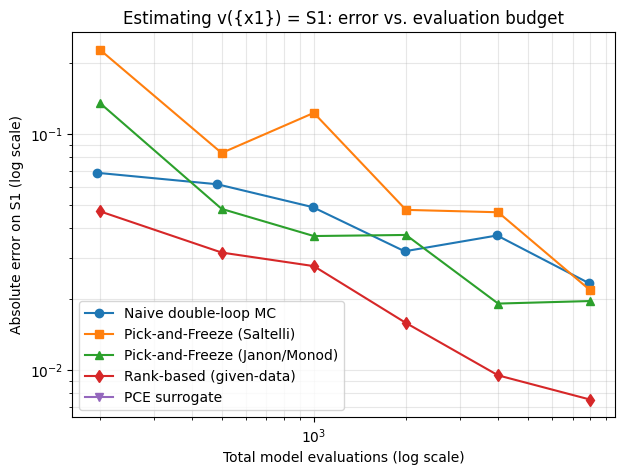

In [ ]:
budgets = [200, 500, 1000, 2000, 4000, 8000]
n_trials = 12

errors_naive, evals_naive = [], []
errors_pf, evals_pf = [], []
errors_janon, evals_janon = [], []
errors_rank, evals_rank = [], []
errors_pce, evals_pce = [], []

for budget in budgets:
    # naive double-loop: split budget between outer/inner roughly evenly (sqrt-ish)
    n_out = max(5, int(np.sqrt(budget)))
    n_in = max(5, budget // n_out)
    naive_errs = []
    for t in range(n_trials):
        r = np.random.default_rng(1000 + t)
        s = naive_double_loop(0, n_out, n_in, r)
        naive_errs.append(abs(s - S_true[0]))
    errors_naive.append(np.mean(naive_errs)); evals_naive.append(n_out * n_in)

    # Pick-and-freeze family: budget = (d+2)*N -> N = budget // (d+2)
    N_pf = max(5, budget // 5)
    saltelli_errs, janon_errs = [], []
    for t in range(n_trials):
        r = np.random.default_rng(2000 + t)
        At, Bt = pick_and_freeze_matrices(N_pf, 3, r)
        saltelli_errs.append(abs(saltelli_first_order(At, Bt, ishigami)[0] - S_true[0]))
        janon_errs.append(abs(janon_first_order(At, Bt, ishigami)[0] - S_true[0]))
    errors_pf.append(np.mean(saltelli_errs)); evals_pf.append(5 * N_pf)
    errors_janon.append(np.mean(janon_errs)); evals_janon.append(5 * N_pf)

    # rank-based: budget = n (a single sample)
    rank_errs = []
    for t in range(n_trials):
        r = np.random.default_rng(3000 + t)
        Xg = sample_inputs(budget, r); Yg = ishigami(Xg)
        rank_errs.append(abs(rank_based_first_order(Xg[:, 0], Yg) - S_true[0]))
    errors_rank.append(np.mean(rank_errs)); evals_rank.append(budget)


plt.figure(figsize=(7, 5))
plt.loglog(evals_naive, errors_naive, 'o-', label='Naive double-loop MC')
plt.loglog(evals_pf, errors_pf, 's-', label='Pick-and-Freeze (Saltelli)')
plt.loglog(evals_janon, errors_janon, '^-', label='Pick-and-Freeze (Janon/Monod)')
plt.loglog(evals_rank, errors_rank, 'd-', label='Rank-based (given-data)')
plt.loglog(evals_pce, errors_pce, 'v-', label='PCE surrogate')
plt.xlabel('Total model evaluations (log scale)')
plt.ylabel('Absolute error on S1 (log scale)')
plt.title('Estimating v({x1}) = S1: error vs. evaluation budget')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()


**Discussion prompt:** which method dominates at small budgets? At large budgets? Is there a
crossover, and does it make sense given what each method assumes (smoothness for PCE,
independence for Pick-and-Freeze, nothing for the rank-based/given-data method)?


## **Bonus : Correlated inputs: why Pick-and-Freeze silently breaks**

Every Pick-and-Freeze estimator above implicitly assumes the inputs are **independent** --
the mixed matrix $A_B^i$ is built by swapping in $B$'s column $i$ *without regard* to what
values the other columns hold, which is only a valid way to sample "$X_i$ replaced,
everything else held fixed" if $X_i$ is independent of the rest. When inputs are correlated,
this silently computes the *wrong* quantity, with no error message -- it just converges
confidently to the wrong number.

We show this with a simple linear-Gaussian model where we can compute the truth analytically:
$Y = X_1 + X_2$, with $(X_1, X_2)$ jointly Gaussian and correlation $\rho = 0.8$.


In [ ]:
rho = 0.8

def sample_joint_correlated(n, rng):
    X1 = rng.normal(0, 1, n)
    X2 = rho * X1 + np.sqrt(1 - rho**2) * rng.normal(0, 1, n)
    return np.column_stack([X1, X2])

def linear_model(X):
    return X[:, 0] + X[:, 1]

# Closed-form for this simple case: Var(Y) = 2 + 2*rho ; Var(E[Y|X1]) = (1+rho)^2
var_Y_analytic = 2 + 2*rho
S1_analytic = (1 + rho)**2 / var_Y_analytic
print("Analytic S1 (correctly accounting for correlation):", round(S1_analytic, 4))


Analytic S1 (correctly accounting for correlation): 0.9


In [ ]:
# --- CORRECT: nested MC that resamples X2 from its TRUE conditional distribution given X1 ---
def true_conditional_nested(n_outer, n_inner, rng):
    X1_outer = rng.normal(0, 1, n_outer)
    inner_means = np.zeros(n_outer)
    for k in range(n_outer):
        x1_fixed = X1_outer[k]
        x2_cond = rho * x1_fixed + np.sqrt(1 - rho**2) * rng.normal(0, 1, n_inner)
        inner_means[k] = linear_model(
            np.column_stack([np.full(n_inner, x1_fixed), x2_cond])).mean()
    Y_ref = linear_model(sample_joint_correlated(20000, rng))
    return inner_means.var() / Y_ref.var()

# --- WRONG (but the usual Pick-and-Freeze default): resamples X2 from its MARGINAL,
#     ignoring that X2 is correlated with X1 ---
def naive_pf_ignoring_correlation(n_outer, n_inner, rng):
    X1_outer = rng.normal(0, 1, n_outer)
    inner_means = np.zeros(n_outer)
    for k in range(n_outer):
        x1_fixed = X1_outer[k]
        x2_indep = rng.normal(0, 1, n_inner)  # <-- ignores the correlation!
        inner_means[k] = linear_model(
            np.column_stack([np.full(n_inner, x1_fixed), x2_indep])).mean()
    Y_ref = linear_model(sample_joint_correlated(20000, rng))
    return inner_means.var() / Y_ref.var()

rng1 = np.random.default_rng(1)
s1_correct = true_conditional_nested(800, 2000, rng1)
rng2 = np.random.default_rng(2)
s1_wrong = naive_pf_ignoring_correlation(800, 2000, rng2)

print(f"{'Method':<45}{'S1 estimate':>14}")
print(f"{'Analytic (ground truth)':<45}{S1_analytic:>14.4f}")
print(f"{'Conditional-respecting nested MC':<45}{s1_correct:>14.4f}")
print(f"{'Naive Pick-and-Freeze (ignores correlation)':<45}{s1_wrong:>14.4f}")


Method                                          S1 estimate
Analytic (ground truth)                              0.9000
Conditional-respecting nested MC                     0.8733
Naive Pick-and-Freeze (ignores correlation)          0.2778


**References for further reading:**
- Sobol, I.M. (1993). *Sensitivity analysis for non-linear mathematical models.*
- Saltelli, A. (2002). *Making best use of model evaluations to compute sensitivity indices.*
- Jansen, M.J.W. (1999). *Analysis of variance designs for model output.*
- Janon, Klein, Lagnoux, Nodet & Prieur (2014). *Asymptotic normality and efficiency of two
  Sobol index estimators.* ESAIM: P&S.
- Gamboa, Gremaud, Klein & Lagnoux (2022). *Global Sensitivity Analysis: a new generation of
  mighty estimators based on rank statistics.* Bernoulli.
- Chatterjee, S. (2021). *A new coefficient of correlation.* JASA.
- Owen, A.B. (2014). *Sobol' indices and Shapley value.*
- Song, Nelson & Staum (2016). *Shapley effects for global sensitivity analysis.*
- Kucherenko, Tarantola & Annoni (2012). *Estimation of global sensitivity indices for models
  with dependent variables.*
- R package `sensitivity` (functions `sobol2002`, `soboljansen`, `sobolEff`, `sobolrank`,
  `shapleysobol_knn`) -- a good reference implementation to cross-check any estimator here.
